# Member 2 — Ablation Study
## CS690R — IRB Stroke Recovery Dataset

This notebook runs 5 ablation experiments on top of the base Random Forest result (AUC=0.780):

| # | Ablation | Question |
|---|---|---|
| 1 | Feature Group (axis) | Which axis contributes most — X, Y, or Z? |
| 2 | Feature Type (statistic) | Do percentiles matter more than means/stds? |
| 3 | Number of Trees | Was 200 trees actually necessary? |
| 4 | Top-K Features | How few features can we get away with? |
| 5 | Classifier | Was Random Forest the right choice? |

All experiments use identical LOSO cross-validation to ensure fair comparison.

---
## 0 — Imports and Setup

In [1]:
import subprocess, sys
for pkg in ['scikit-learn', 'seaborn', 'matplotlib', 'pandas', 'numpy']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

In [2]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.model_selection import LeaveOneGroupOut

warnings.filterwarnings('ignore')

FEATURES_PATH = 'features/biopm_features.npz'
FIGURES_DIR   = 'results/figures'
METRICS_DIR   = 'results/metrics'
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('Imports OK')

Imports OK


---
## 1 — Load Data

In [3]:
d = np.load(FEATURES_PATH, allow_pickle=True)

X             = d['features'].astype(np.float64)   # (198, 228)
y             = d['labels'].astype(int)            # (198,)
pids          = d['pids'].astype(int)              # (198,)
feature_names = d['feature_names']                 # (228,)

# Load the pre-computed feature importances from the base RF run
# (produced by member2_random_forest_irb.ipynb)
importance_df = pd.read_csv(
    os.path.join(METRICS_DIR, 'rf_feature_importances_irb.csv')
)

BASE_AUC = 0.780   # pooled AUC from base RF run

print(f'X: {X.shape}, y: {y.shape}, subjects: {len(np.unique(pids))}')
print(f'Base AUC (all features, RF 200 trees): {BASE_AUC}')

X: (198, 228), y: (198,), subjects: 36
Base AUC (all features, RF 200 trees): 0.78


---
## 2 — Shared LOSO Helper

All ablations call the same function — only the feature subset or classifier changes.
This guarantees apples-to-apples comparison across experiments.

In [4]:
def run_loso(X_sub, y, pids, clf_fn):
    """
    Run LOSO cross-validation with a given feature subset and classifier.

    Parameters
    ----------
    X_sub  : (N, F) feature matrix — already subsetted to desired features
    y      : (N,) binary labels
    pids   : (N,) subject IDs for LOSO grouping
    clf_fn : callable that returns a fresh sklearn classifier

    Returns
    -------
    pooled_auc : float
    pooled_f1  : float
    """
    logo      = LeaveOneGroupOut()
    all_probs = np.zeros(len(y))
    all_preds = np.zeros(len(y), dtype=int)

    for train_idx, test_idx in logo.split(X_sub, y, pids):
        X_train, X_test = X_sub[train_idx], X_sub[test_idx]
        y_train         = y[train_idx]

        scaler  = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)

        clf = clf_fn()
        clf.fit(X_train, y_train)

        all_probs[test_idx] = clf.predict_proba(X_test)[:, 1]
        all_preds[test_idx] = clf.predict(X_test)

    pooled_auc = roc_auc_score(y, all_probs)
    pooled_f1  = f1_score(y, all_preds, zero_division=0)
    return round(pooled_auc, 4), round(pooled_f1, 4)


def rf_fn(n_estimators=200):
    """Returns a factory function for a RF with given n_estimators."""
    return lambda: RandomForestClassifier(
        n_estimators=n_estimators,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

print('Helper functions defined')

Helper functions defined


---
## Ablation 1 — Feature Group (Axis)

**Question:** Which axis (X, Y, Z, or magnitude) contributes most to classification?

We split the 228 features into groups based on their prefix (X_, Y_, Z_, acc_mag_)
and run the RF on each group separately, then compare to the full 228-feature baseline.

In [5]:
# Define axis groups based on feature name prefixes
axis_groups = {
    'Y-axis only'    : [i for i, n in enumerate(feature_names) if n.startswith('Y_')],
    'Z-axis only'    : [i for i, n in enumerate(feature_names) if n.startswith('Z_')],
    'X-axis only'    : [i for i, n in enumerate(feature_names) if n.startswith('X_')],
    'Magnitude only' : [i for i, n in enumerate(feature_names) if n.startswith('acc_mag')],
    'All axes'       : list(range(len(feature_names))),
}

print('Feature counts per group:')
for name, idx in axis_groups.items():
    print(f'  {name:20s}: {len(idx)} features')

Feature counts per group:
  Y-axis only         : 54 features
  Z-axis only         : 54 features
  X-axis only         : 54 features
  Magnitude only      : 18 features
  All axes            : 228 features


In [6]:
ablation1_rows = []

for group_name, feat_idx in axis_groups.items():
    print(f'Running: {group_name} ({len(feat_idx)} features)...', end=' ')
    t0 = time.time()
    auc, f1 = run_loso(X[:, feat_idx], y, pids, rf_fn(200))
    elapsed = time.time() - t0
    ablation1_rows.append({
        'Group'         : group_name,
        'N Features'    : len(feat_idx),
        'Pooled AUC'    : auc,
        'Pooled F1'     : f1,
        'vs Baseline'   : f'{auc - BASE_AUC:+.3f}',
    })
    print(f'AUC={auc:.3f}  ({elapsed:.1f}s)')

ablation1_df = pd.DataFrame(ablation1_rows).sort_values('Pooled AUC', ascending=False)
ablation1_df.to_csv(os.path.join(METRICS_DIR, 'ablation1_axis_irb.csv'), index=False)
print('\n', ablation1_df.to_string(index=False))

Running: Y-axis only (54 features)... AUC=0.883  (17.0s)
Running: Z-axis only (54 features)... AUC=0.742  (16.4s)
Running: X-axis only (54 features)... AUC=0.624  (17.0s)
Running: Magnitude only (18 features)... AUC=0.622  (17.0s)
Running: All axes (228 features)... AUC=0.780  (17.7s)

          Group  N Features  Pooled AUC  Pooled F1 vs Baseline
   Y-axis only          54      0.8834     0.9898      +0.103
      All axes         228      0.7803     0.9898      +0.000
   Z-axis only          54      0.7423     0.9898      -0.038
   X-axis only          54      0.6237     0.9898      -0.156
Magnitude only          18      0.6218     0.9898      -0.158


---
## Ablation 2 — Feature Type (Statistic)

**Question:** Do percentile features (p10, p50, p90) carry more signal than
mean, std, or IQR features?

We group by the suffix of each feature name.

In [7]:
# Group by statistic type (suffix after last underscore)
def get_stat_type(name):
    if any(name.endswith(s) for s in ['p10', 'p50', 'p90']):
        return 'Percentiles (p10/p50/p90)'
    elif 'mean' in name.split('_'):
        return 'Mean'
    elif 'std' in name.split('_'):
        return 'Std'
    elif 'iqr' in name.lower():
        return 'IQR'
    elif 'max' in name.split('_'):
        return 'Max'
    else:
        return 'Other'

stat_groups = {}
for i, name in enumerate(feature_names):
    stat = get_stat_type(name)
    stat_groups.setdefault(stat, []).append(i)

# Add full baseline
stat_groups['All types'] = list(range(len(feature_names)))

print('Feature counts per statistic type:')
for name, idx in stat_groups.items():
    print(f'  {name:30s}: {len(idx)} features')

Feature counts per statistic type:
  Mean                          : 62 features
  Percentiles (p10/p50/p90)     : 114 features
  Std                           : 38 features
  IQR                           : 14 features
  All types                     : 228 features


In [8]:
ablation2_rows = []

for stat_name, feat_idx in stat_groups.items():
    if len(feat_idx) < 2:
        continue
    print(f'Running: {stat_name} ({len(feat_idx)} features)...', end=' ')
    t0 = time.time()
    auc, f1 = run_loso(X[:, feat_idx], y, pids, rf_fn(200))
    elapsed = time.time() - t0
    ablation2_rows.append({
        'Statistic Type' : stat_name,
        'N Features'     : len(feat_idx),
        'Pooled AUC'     : auc,
        'Pooled F1'      : f1,
        'vs Baseline'    : f'{auc - BASE_AUC:+.3f}',
    })
    print(f'AUC={auc:.3f}  ({elapsed:.1f}s)')

ablation2_df = pd.DataFrame(ablation2_rows).sort_values('Pooled AUC', ascending=False)
ablation2_df.to_csv(os.path.join(METRICS_DIR, 'ablation2_stattype_irb.csv'), index=False)
print('\n', ablation2_df.to_string(index=False))

Running: Mean (62 features)... AUC=0.653  (17.2s)
Running: Percentiles (p10/p50/p90) (114 features)... AUC=0.793  (16.7s)
Running: Std (38 features)... AUC=0.741  (16.3s)
Running: IQR (14 features)... AUC=0.635  (17.2s)
Running: All types (228 features)... AUC=0.780  (16.7s)

            Statistic Type  N Features  Pooled AUC  Pooled F1 vs Baseline
Percentiles (p10/p50/p90)         114      0.7932     0.9898      +0.013
                All types         228      0.7803     0.9898      +0.000
                      Std          38      0.7410     0.9898      -0.039
                     Mean          62      0.6527     0.9898      -0.127
                      IQR          14      0.6347     0.9898      -0.145


---
## Ablation 3 — Number of Trees

**Question:** Was 200 trees actually necessary, or does performance plateau earlier?

More trees = more stable predictions but more compute time. This ablation finds
the minimum number of trees that achieves near-baseline performance.

In [9]:
tree_counts = [10, 25, 50, 100, 150, 200, 300, 500]
ablation3_rows = []

for n_trees in tree_counts:
    print(f'Running: {n_trees} trees...', end=' ')
    t0 = time.time()
    auc, f1 = run_loso(X, y, pids, rf_fn(n_trees))
    elapsed = time.time() - t0
    ablation3_rows.append({
        'N Trees'     : n_trees,
        'Pooled AUC'  : auc,
        'Pooled F1'   : f1,
        'vs Baseline' : f'{auc - BASE_AUC:+.3f}',
        'Time (s)'    : round(elapsed, 1),
    })
    print(f'AUC={auc:.3f}  ({elapsed:.1f}s)')

ablation3_df = pd.DataFrame(ablation3_rows)
ablation3_df.to_csv(os.path.join(METRICS_DIR, 'ablation3_ntrees_irb.csv'), index=False)
print('\n', ablation3_df.to_string(index=False))

Running: 10 trees... AUC=0.551  (3.4s)
Running: 25 trees... AUC=0.619  (4.1s)
Running: 50 trees... AUC=0.706  (6.2s)
Running: 100 trees... AUC=0.780  (9.8s)
Running: 150 trees... AUC=0.783  (12.6s)
Running: 200 trees... AUC=0.780  (16.5s)
Running: 300 trees... AUC=0.785  (23.6s)
Running: 500 trees... AUC=0.787  (37.4s)

  N Trees  Pooled AUC  Pooled F1 vs Baseline  Time (s)
      10      0.5515     0.9898      -0.229       3.4
      25      0.6192     0.9898      -0.161       4.1
      50      0.7055     0.9898      -0.075       6.2
     100      0.7803     0.9898      +0.000       9.8
     150      0.7829     0.9898      +0.003      12.6
     200      0.7803     0.9898      +0.000      16.5
     300      0.7848     0.9898      +0.005      23.6
     500      0.7874     0.9898      +0.007      37.4


---
## Ablation 4 — Top-K Features

**Question:** How few features can we use while maintaining near-baseline AUC?

Features are ranked by the importance scores from the base RF run.
Clinically, a smaller feature set = fewer measurements needed = simpler tool.

In [10]:
# Use the pre-computed importance ranking
ranked_features = importance_df['feature'].tolist()   # already sorted best→worst
feature_name_list = list(feature_names)
ranked_indices = [feature_name_list.index(f) for f in ranked_features]

k_values = [5, 10, 20, 30, 50, 75, 100, 150, 228]
ablation4_rows = []

for k in k_values:
    top_k_idx = ranked_indices[:k]
    print(f'Running: top {k} features...', end=' ')
    t0 = time.time()
    auc, f1 = run_loso(X[:, top_k_idx], y, pids, rf_fn(200))
    elapsed = time.time() - t0
    ablation4_rows.append({
        'Top-K Features' : k,
        'Pooled AUC'     : auc,
        'Pooled F1'      : f1,
        'vs Baseline'    : f'{auc - BASE_AUC:+.3f}',
        'Time (s)'       : round(elapsed, 1),
    })
    print(f'AUC={auc:.3f}  ({elapsed:.1f}s)')

ablation4_df = pd.DataFrame(ablation4_rows)
ablation4_df.to_csv(os.path.join(METRICS_DIR, 'ablation4_topk_irb.csv'), index=False)
print('\n', ablation4_df.to_string(index=False))

Running: top 5 features... AUC=0.959  (16.8s)
Running: top 10 features... AUC=0.957  (16.8s)
Running: top 20 features... AUC=0.934  (16.2s)
Running: top 30 features... AUC=0.930  (16.7s)
Running: top 50 features... AUC=0.867  (16.7s)
Running: top 75 features... AUC=0.883  (16.9s)
Running: top 100 features... AUC=0.822  (16.4s)
Running: top 150 features... AUC=0.833  (16.8s)
Running: top 228 features... AUC=0.650  (16.7s)

  Top-K Features  Pooled AUC  Pooled F1 vs Baseline  Time (s)
              5      0.9588     0.9898      +0.179      16.8
             10      0.9568     0.9898      +0.177      16.8
             20      0.9343     0.9898      +0.154      16.2
             30      0.9304     0.9898      +0.150      16.7
             50      0.8666     0.9898      +0.087      16.7
             75      0.8834     0.9898      +0.103      16.9
            100      0.8215     0.9898      +0.041      16.4
            150      0.8331     0.9898      +0.053      16.8
            228      0.6

---
## Ablation 5 — Classifier Comparison

**Question:** Was Random Forest the right classifier, or would a simpler/different
model do just as well?

All classifiers use the same LOSO setup and StandardScaler inside each fold.

In [11]:
classifiers = {
    'Random Forest (200)'   : rf_fn(200),
    'Gradient Boosting'     : lambda: GradientBoostingClassifier(
                                  n_estimators=100, random_state=42),
    'Logistic Regression'   : lambda: LogisticRegression(
                                  class_weight='balanced', max_iter=1000,
                                  random_state=42),
    'SVM (RBF kernel)'      : lambda: SVC(
                                  kernel='rbf', class_weight='balanced',
                                  probability=True, random_state=42),
}

ablation5_rows = []

for clf_name, clf_fn_inst in classifiers.items():
    print(f'Running: {clf_name}...', end=' ')
    t0 = time.time()
    auc, f1 = run_loso(X, y, pids, clf_fn_inst)
    elapsed = time.time() - t0
    ablation5_rows.append({
        'Classifier'  : clf_name,
        'Pooled AUC'  : auc,
        'Pooled F1'   : f1,
        'vs Baseline' : f'{auc - BASE_AUC:+.3f}',
        'Time (s)'    : round(elapsed, 1),
    })
    print(f'AUC={auc:.3f}  ({elapsed:.1f}s)')

ablation5_df = pd.DataFrame(ablation5_rows).sort_values('Pooled AUC', ascending=False)
ablation5_df.to_csv(os.path.join(METRICS_DIR, 'ablation5_classifier_irb.csv'), index=False)
print('\n', ablation5_df.to_string(index=False))

Running: Random Forest (200)... AUC=0.780  (17.6s)
Running: Gradient Boosting... AUC=0.280  (57.2s)
Running: Logistic Regression... AUC=0.682  (0.9s)
Running: SVM (RBF kernel)... AUC=0.139  (0.5s)

          Classifier  Pooled AUC  Pooled F1 vs Baseline  Time (s)
Random Forest (200)      0.7803     0.9898      +0.000      17.6
Logistic Regression      0.6817     0.9549      -0.098       0.9
  Gradient Boosting      0.2796     0.9846      -0.500      57.2
   SVM (RBF kernel)      0.1392     0.9239      -0.641       0.5


---
## Figures — All Ablations Visualized

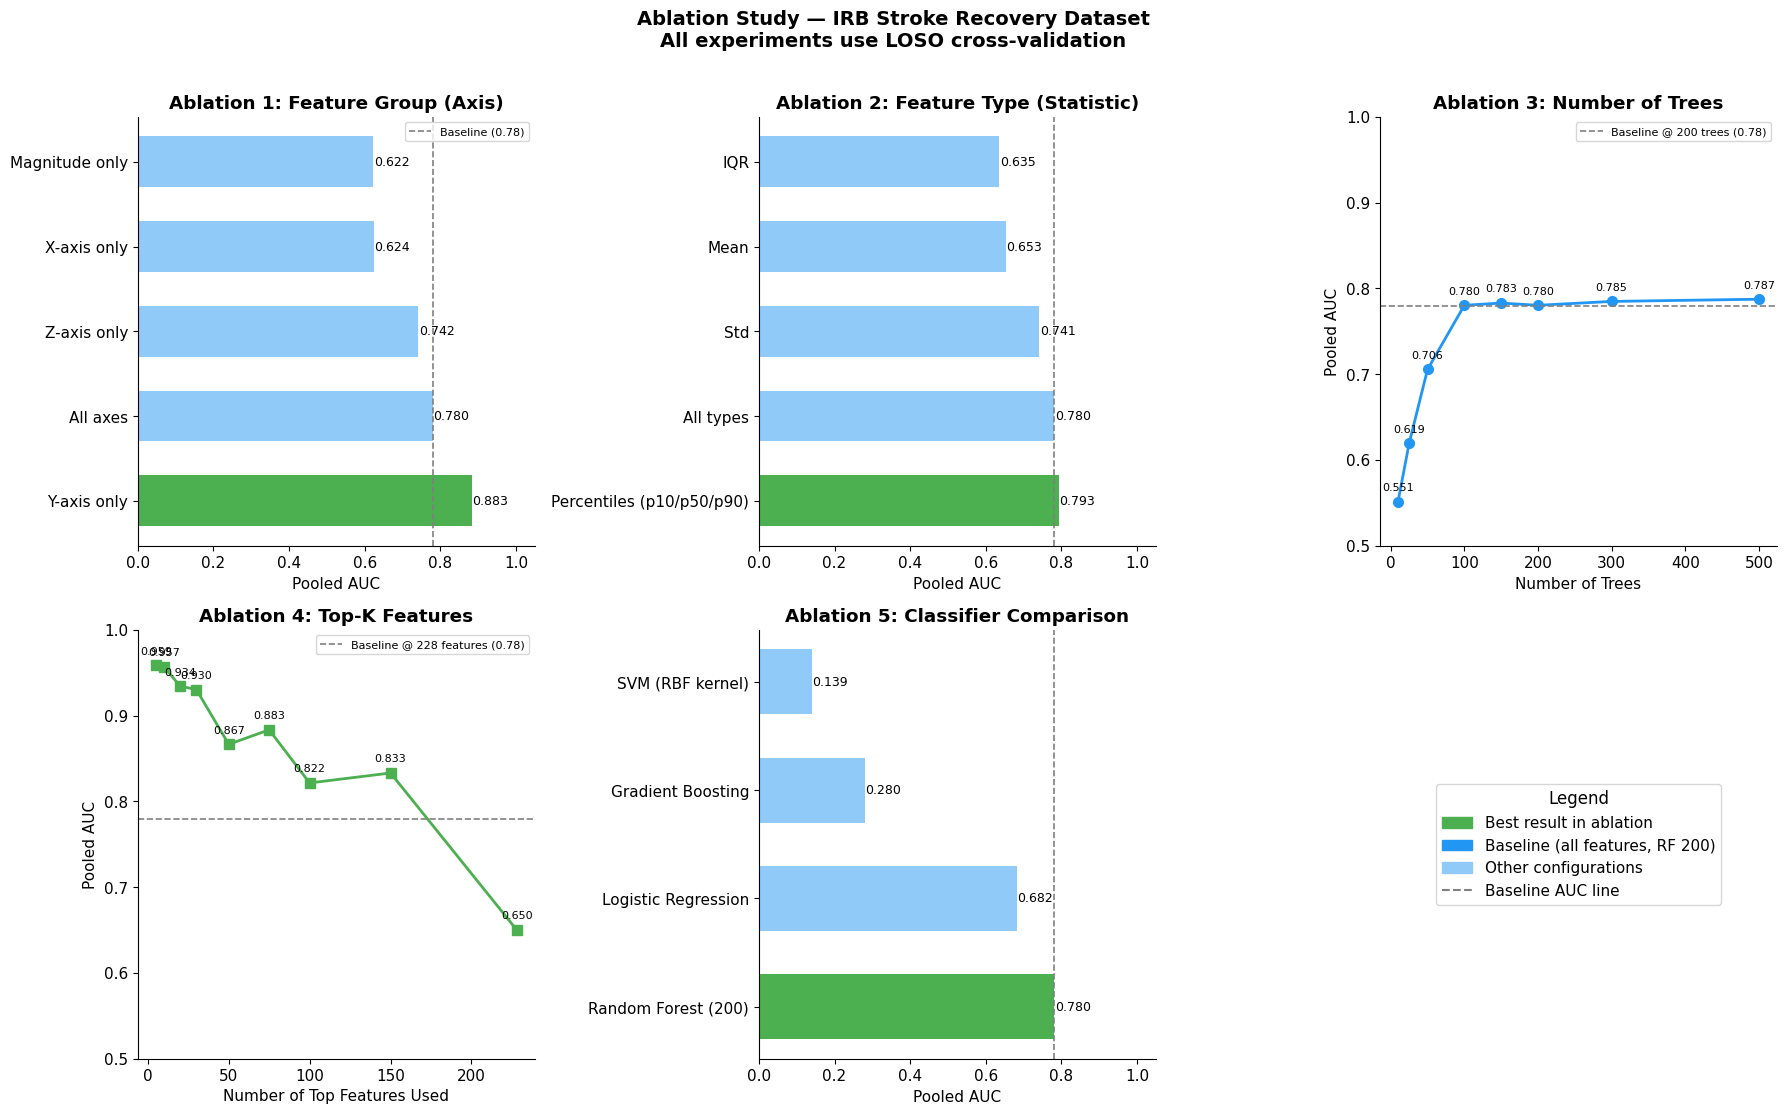

Saved → results/figures\ablation_summary_irb.png


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
BASE_COLOR  = '#2196F3'
BEST_COLOR  = '#4CAF50'
OTHER_COLOR = '#90CAF9'

def bar_colors(values, baseline):
    best = max(values)
    return [BEST_COLOR if v == best else (BASE_COLOR if v == baseline else OTHER_COLOR)
            for v in values]

# ── Ablation 1: Axis ─────────────────────────────────────────────────────────
ax = axes[0, 0]
df = ablation1_df
colors = bar_colors(df['Pooled AUC'].tolist(), BASE_AUC)
bars = ax.barh(df['Group'], df['Pooled AUC'], color=colors, height=0.6)
ax.axvline(BASE_AUC, color='gray', linestyle='--', linewidth=1.2, label=f'Baseline ({BASE_AUC})')
for bar, val in zip(bars, df['Pooled AUC']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('Pooled AUC')
ax.set_title('Ablation 1: Feature Group (Axis)', fontweight='bold')
ax.set_xlim(0, 1.05)
ax.legend(fontsize=8)

# ── Ablation 2: Stat Type ─────────────────────────────────────────────────────
ax = axes[0, 1]
df = ablation2_df
colors = bar_colors(df['Pooled AUC'].tolist(), BASE_AUC)
bars = ax.barh(df['Statistic Type'], df['Pooled AUC'], color=colors, height=0.6)
ax.axvline(BASE_AUC, color='gray', linestyle='--', linewidth=1.2)
for bar, val in zip(bars, df['Pooled AUC']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('Pooled AUC')
ax.set_title('Ablation 2: Feature Type (Statistic)', fontweight='bold')
ax.set_xlim(0, 1.05)

# ── Ablation 3: N Trees ───────────────────────────────────────────────────────
ax = axes[0, 2]
df = ablation3_df
ax.plot(df['N Trees'], df['Pooled AUC'], 'o-', color=BASE_COLOR,
        linewidth=2, markersize=7)
ax.axhline(BASE_AUC, color='gray', linestyle='--', linewidth=1.2,
           label=f'Baseline @ 200 trees ({BASE_AUC})')
for _, row in df.iterrows():
    ax.annotate(f'{row["Pooled AUC"]:.3f}',
                xy=(row['N Trees'], row['Pooled AUC']),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=8)
ax.set_xlabel('Number of Trees')
ax.set_ylabel('Pooled AUC')
ax.set_title('Ablation 3: Number of Trees', fontweight='bold')
ax.legend(fontsize=8)
ax.set_ylim(0.5, 1.0)

# ── Ablation 4: Top-K ─────────────────────────────────────────────────────────
ax = axes[1, 0]
df = ablation4_df
ax.plot(df['Top-K Features'], df['Pooled AUC'], 's-', color=BEST_COLOR,
        linewidth=2, markersize=7)
ax.axhline(BASE_AUC, color='gray', linestyle='--', linewidth=1.2,
           label=f'Baseline @ 228 features ({BASE_AUC})')
for _, row in df.iterrows():
    ax.annotate(f'{row["Pooled AUC"]:.3f}',
                xy=(row['Top-K Features'], row['Pooled AUC']),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=8)
ax.set_xlabel('Number of Top Features Used')
ax.set_ylabel('Pooled AUC')
ax.set_title('Ablation 4: Top-K Features', fontweight='bold')
ax.legend(fontsize=8)
ax.set_ylim(0.5, 1.0)

# ── Ablation 5: Classifier ────────────────────────────────────────────────────
ax = axes[1, 1]
df = ablation5_df
colors = bar_colors(df['Pooled AUC'].tolist(), BASE_AUC)
bars = ax.barh(df['Classifier'], df['Pooled AUC'], color=colors, height=0.6)
ax.axvline(BASE_AUC, color='gray', linestyle='--', linewidth=1.2)
for bar, val in zip(bars, df['Pooled AUC']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('Pooled AUC')
ax.set_title('Ablation 5: Classifier Comparison', fontweight='bold')
ax.set_xlim(0, 1.05)

# ── Legend panel ──────────────────────────────────────────────────────────────
ax = axes[1, 2]
ax.axis('off')
legend_elements = [
    mpatches.Patch(color=BEST_COLOR,  label='Best result in ablation'),
    mpatches.Patch(color=BASE_COLOR,  label='Baseline (all features, RF 200)'),
    mpatches.Patch(color=OTHER_COLOR, label='Other configurations'),
    plt.Line2D([0], [0], color='gray', linestyle='--', label='Baseline AUC line'),
]
ax.legend(handles=legend_elements, loc='center', fontsize=11, frameon=True,
          title='Legend', title_fontsize=12)

fig.suptitle('Ablation Study — IRB Stroke Recovery Dataset\nAll experiments use LOSO cross-validation',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
out = os.path.join(FIGURES_DIR, 'ablation_summary_irb.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')

---
## Master Summary Table

In [13]:
print('=' * 65)
print('  ABLATION STUDY SUMMARY — IRB Stroke Recovery Dataset')
print('=' * 65)

print(f'\n  Baseline: All 228 features, RF 200 trees → AUC = {BASE_AUC}\n')

sections = [
    ('ABLATION 1 — Feature Group (Axis)',    ablation1_df, 'Group'),
    ('ABLATION 2 — Statistic Type',          ablation2_df, 'Statistic Type'),
    ('ABLATION 3 — Number of Trees',         ablation3_df, 'N Trees'),
    ('ABLATION 4 — Top-K Features',          ablation4_df, 'Top-K Features'),
    ('ABLATION 5 — Classifier Comparison',   ablation5_df, 'Classifier'),
]

for title, df, key_col in sections:
    print(f'  {title}')
    print(f'  {"-" * 60}')
    sub = df[[key_col, 'Pooled AUC', 'vs Baseline']].copy()
    for _, row in sub.iterrows():
        marker = ' ← BEST' if row['Pooled AUC'] == df['Pooled AUC'].max() else ''
        print(f'  {str(row[key_col]):30s}  AUC={row["Pooled AUC"]:.3f}  ({row["vs Baseline"]}){marker}')
    print()

print('=' * 65)

  ABLATION STUDY SUMMARY — IRB Stroke Recovery Dataset

  Baseline: All 228 features, RF 200 trees → AUC = 0.78

  ABLATION 1 — Feature Group (Axis)
  ------------------------------------------------------------
  Y-axis only                     AUC=0.883  (+0.103) ← BEST
  All axes                        AUC=0.780  (+0.000)
  Z-axis only                     AUC=0.742  (-0.038)
  X-axis only                     AUC=0.624  (-0.156)
  Magnitude only                  AUC=0.622  (-0.158)

  ABLATION 2 — Statistic Type
  ------------------------------------------------------------
  Percentiles (p10/p50/p90)       AUC=0.793  (+0.013) ← BEST
  All types                       AUC=0.780  (+0.000)
  Std                             AUC=0.741  (-0.039)
  Mean                            AUC=0.653  (-0.127)
  IQR                             AUC=0.635  (-0.145)

  ABLATION 3 — Number of Trees
  ------------------------------------------------------------
  10                              AUC=0.551  

---
## Output Checklist

In [14]:
expected = [
    (os.path.join(METRICS_DIR, 'ablation1_axis_irb.csv'),       'Ablation 1 — axis results'),
    (os.path.join(METRICS_DIR, 'ablation2_stattype_irb.csv'),   'Ablation 2 — stat type results'),
    (os.path.join(METRICS_DIR, 'ablation3_ntrees_irb.csv'),     'Ablation 3 — n trees results'),
    (os.path.join(METRICS_DIR, 'ablation4_topk_irb.csv'),       'Ablation 4 — top-k results'),
    (os.path.join(METRICS_DIR, 'ablation5_classifier_irb.csv'), 'Ablation 5 — classifier results'),
    (os.path.join(FIGURES_DIR, 'ablation_summary_irb.png'),     'Ablation summary figure'),
]

print('Output files:')
for path, desc in expected:
    status = '✅' if os.path.exists(path) else '❌ MISSING'
    print(f'  {status}  {path}  —  {desc}')

Output files:
  ✅  results/metrics\ablation1_axis_irb.csv  —  Ablation 1 — axis results
  ✅  results/metrics\ablation2_stattype_irb.csv  —  Ablation 2 — stat type results
  ✅  results/metrics\ablation3_ntrees_irb.csv  —  Ablation 3 — n trees results
  ✅  results/metrics\ablation4_topk_irb.csv  —  Ablation 4 — top-k results
  ✅  results/metrics\ablation5_classifier_irb.csv  —  Ablation 5 — classifier results
  ✅  results/figures\ablation_summary_irb.png  —  Ablation summary figure
